# TRABAJO PRACTICO INTEGRAL N°1

## Integrantes:

**CRISTIAN DAMIAN FORTUNESKY BARRIOS**

**MATIAS DE VIVO**

## Actividad 1: Imagen obtenida mediante camara oscura


In [1]:
from pathlib import Path

try:
    import cv2
except ImportError as e:
    raise RuntimeError(
        "OpenCV no esta disponible. Instala opencv-python-headless o agrega libGL.so.1 en el sistema."
    ) from e

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

## Actividad 2: Imagen de medio grafico color

En este caso el problema puede estar en la geometria, en el contraste, en el color o en danos localizados. Antes de intervenir, conviene distinguir si el principal obstaculo es la perspectiva, la cromaticidad, la iluminacion o la presencia de manchas.

Sugerencias tecnicas posibles: rectificacion de perspectiva, mejora sobre HSV o LAB, CLAHE, suavizado e inpainting si hubiera dano localizado.

In [ ]:
# --- Configuración de rutas para Actividades 2 y 3 ---

# Definimos la carpeta base del TFI para que todas las rutas sean reproducibles.
carpeta_tfi = Path("005 - TFI_1")

# Definimos la carpeta de entrada de imágenes.
carpeta_imagenes_tfi = carpeta_tfi / "img_input_tfi1"

# Creamos la carpeta si no existe para evitar errores de lectura/escritura.
carpeta_imagenes_tfi.mkdir(parents=True, exist_ok=True)

# Definimos carpeta de salidas para resultados procesados.
carpeta_salidas_tfi = carpeta_tfi / "img_output_tfi1"
carpeta_salidas_tfi.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de imágenes: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta de salidas: {carpeta_salidas_tfi.resolve()}")

Carpeta de imágenes: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\imagenes_tfi1
Carpeta de salidas: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\salidas_tfi


In [39]:
def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    """Abre una imagen en escala de grises."""
    # Leemos la imagen directamente como grises.
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    # Verificamos que la lectura haya sido correcta.
    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    """Muestra una sola imagen con un titulo."""
    # Definimos el tamano general de la figura.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Elegimos el mapa de color segun la cantidad de dimensiones.
    mapa_de_color = None
    if imagen.ndim == 2:
        mapa_de_color = "gray"

    # Dibujamos la imagen y su titulo.
    plt.imshow(imagen, cmap=mapa_de_color)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    """Muestra una comparacion simple entre dos imagenes."""
    # Creamos una figura con dos ejes lado a lado.
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Definimos el mapa de color para la imagen izquierda.
    mapa_izquierda = None
    if imagen_izquierda.ndim == 2:
        mapa_izquierda = "gray"

    # Dibujamos la imagen izquierda.
    ejes[0].imshow(imagen_izquierda, cmap=mapa_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    # Definimos el mapa de color para la imagen derecha.
    mapa_derecha = None
    if imagen_derecha.ndim == 2:
        mapa_derecha = "gray"

    # Dibujamos la imagen derecha.
    ejes[1].imshow(imagen_derecha, cmap=mapa_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    """Muestra el histograma en grises de una imagen color o gris."""
    # Convertimos a grises si la imagen viene en color.
    imagen_gris = imagen
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva del histograma.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    """Muestra la imagen color y sus tres canales por separado."""
    # Extraemos los tres canales principales.
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    # Creamos una figura de cuatro paneles.
    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Mostramos la imagen original.
    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos el canal rojo.
    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos el canal verde.
    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos el canal azul.
    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    """Guarda una imagen RGB en disco."""
    # Convertimos la imagen a BGR para que OpenCV la guarde correctamente.
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Guardamos la imagen en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    """Guarda una imagen en escala de grises."""
    # Guardamos la imagen directamente en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_gris)


Working dir: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1
Ruta usada: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\img\img-medio-grafico-color.jpg
Existe: False
Buscando archivo en el proyecto...
Encontrado en: c:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\imagenes_tfi1\img-medio-grafico-color.jpg


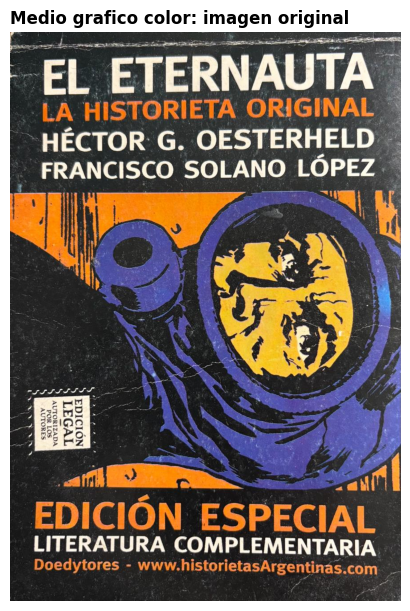

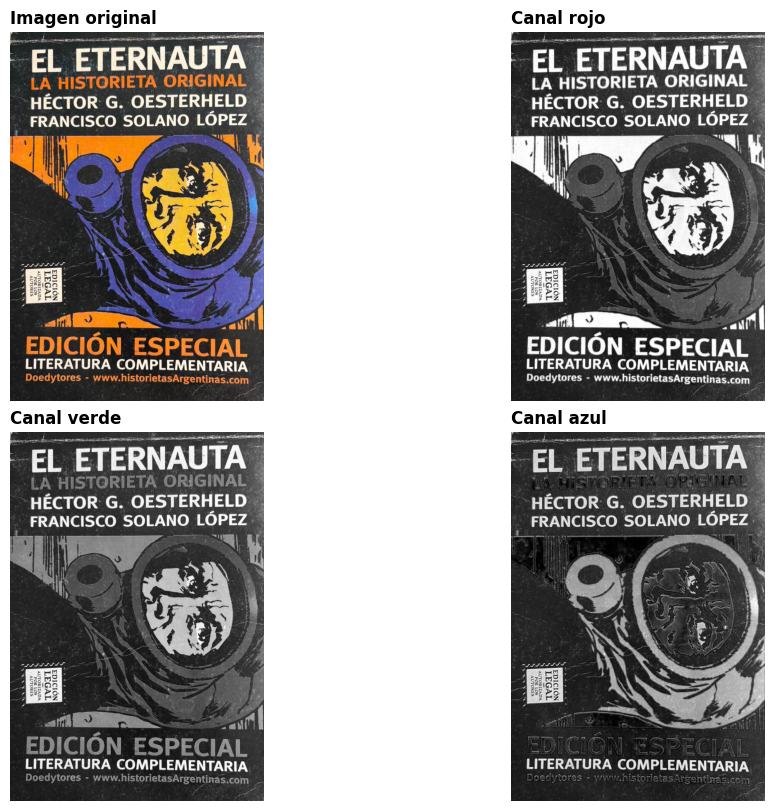


Diagnostico inicial: La imagen es la tapa de un libro fotografiada con luz ambiente cálida. Presenta una dominante amarillenta que apaga los colores originales: el naranja pierde viveza y el azul/violeta aparece desaturado. Además se observan rayaduras blancas localizadas sobre el fondo negro y una leve pérdida de contraste general por la iluminación indirecta.
Objetivo de mejora: Recuperar la saturación y el balance de color de la tapa, corrigiendo la dominante cálida para que el naranja y el azul se acerquen a sus valores originales de impresión.


In [40]:
from pathlib import Path
import os

# =========================
# CONFIG
# =========================
nombre_imagen_medio_color = "img-medio-grafico-color.jpg"

# =========================
# DEBUG (opcional pero útil)
# =========================
print("Working dir:", os.getcwd())

# =========================
# CARGA SEGURA
# =========================
imagen_medio_color_rgb = None

if nombre_imagen_medio_color != "":
    base = Path.cwd()

    # Ruta esperada
    ruta_medio_color = base / "005 - TFI_1" / "img" / nombre_imagen_medio_color

    print("Ruta usada:", ruta_medio_color)
    print("Existe:", ruta_medio_color.exists())

    # Si no existe, buscar automáticamente en todo el proyecto
    if not ruta_medio_color.exists():
        print("Buscando archivo en el proyecto...")
        encontrados = list(base.rglob(nombre_imagen_medio_color))
        
        if len(encontrados) > 0:
            ruta_medio_color = encontrados[0]
            print("Encontrado en:", ruta_medio_color)
        else:
            raise FileNotFoundError(f"No se encontró {nombre_imagen_medio_color} en el proyecto")

    # Cargar imagen
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Mostrar (asegurate de haber ejecutado las funciones antes)
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)

# =========================
# TEXTO
# =========================
diagnostico_medio_color = (
    "La imagen es la tapa de un libro fotografiada con luz ambiente cálida. "
    "Presenta una dominante amarillenta que apaga los colores originales: "
    "el naranja pierde viveza y el azul/violeta aparece desaturado. "
    "Además se observan rayaduras blancas localizadas sobre el fondo negro "
    "y una leve pérdida de contraste general por la iluminación indirecta."
)

objetivo_medio_color = (
    "Recuperar la saturación y el balance de color de la tapa, corrigiendo "
    "la dominante cálida para que el naranja y el azul se acerquen a sus "
    "valores originales de impresión."
)

print("\nDiagnostico inicial:", diagnostico_medio_color)
print("Objetivo de mejora:", objetivo_medio_color)

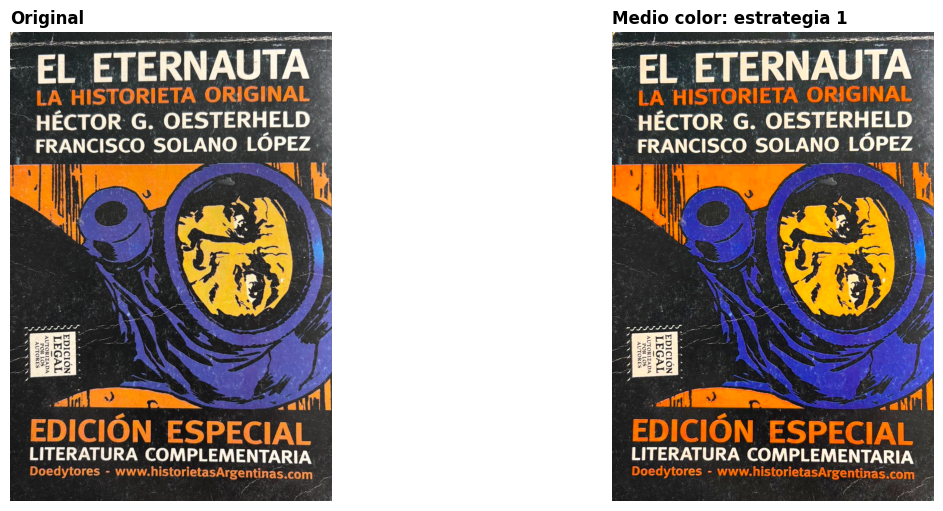

La mejora en HSV incrementa la saturación de todos los colores por igual. El naranja y el azul ganan viveza, pero la dominante cálida no se corrige: como el tono (H) no se toca, el sesgo amarillento de la iluminación se mantiene. El resultado es más vistoso pero no más fiel al color original de impresión.


In [41]:
imagen_medio_color_estrategia_1 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # Convertimos a HSV para manipular saturación e intensidad por separado.
    # En HSV el canal S controla la viveza del color sin afectar el tono (H).
    hsv = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2HSV).astype("float32")

    # Subimos la saturación un 40%. Si el valor supera 255 lo recortamos.
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.4, 0, 255)

    # También subimos levemente el brillo para compensar la luz ambiente oscura.
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.1, 0, 255)

    imagen_medio_color_estrategia_1 = cv2.cvtColor(
        hsv.astype("uint8"), cv2.COLOR_HSV2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )

observacion_medio_color_estrategia_1 = (
    "La mejora en HSV incrementa la saturación de todos los colores por igual. "
    "El naranja y el azul ganan viveza, pero la dominante cálida no se corrige: "
    "como el tono (H) no se toca, el sesgo amarillento de la iluminación se mantiene. "
    "El resultado es más vistoso pero no más fiel al color original de impresión."
)
print(observacion_medio_color_estrategia_1)

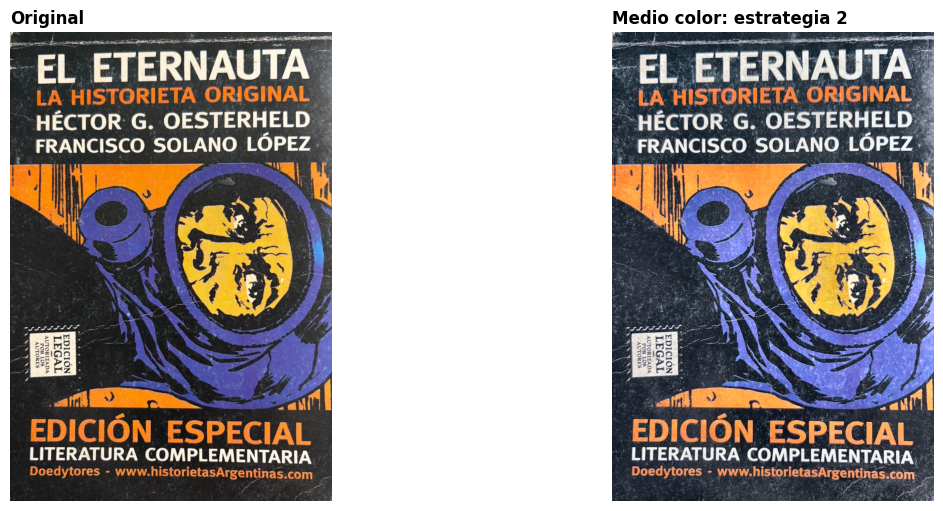

La corrección en LAB actúa sobre dos problemas por separado: CLAHE mejora el contraste en L sin afectar el color, y restar del canal B reduce la dominante amarillenta de la luz ambiente. El azul/violeta del personaje y el naranja del fondo quedan más equilibrados entre sí. A diferencia de HSV, esta estrategia corrige el sesgo de color además de mejorar la viveza general.


In [42]:
imagen_medio_color_estrategia_2 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy()

    # Convertimos a LAB. En este espacio:
    # L = luminosidad, A = eje verde-rojo, B = eje azul-amarillo.
    # La dominante cálida se manifiesta como exceso en el canal B (más amarillo).
    lab = cv2.cvtColor(imagen_medio_color_estrategia_2, cv2.COLOR_RGB2LAB).astype("float32")

    # Aplicamos CLAHE sobre L para mejorar contraste sin saturar zonas ya claras.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0].astype("uint8"))

    # Corregimos la dominante restando del canal B (reducimos el exceso de amarillo).
    # El valor 8 fue elegido observando que la dominante es moderada, no extrema.
    lab[:, :, 2] = np.clip(lab[:, :, 2] - 8, 0, 255)

    imagen_medio_color_estrategia_2 = cv2.cvtColor(
        lab.astype("uint8"), cv2.COLOR_LAB2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )

observacion_medio_color_estrategia_2 = (
    "La corrección en LAB actúa sobre dos problemas por separado: "
    "CLAHE mejora el contraste en L sin afectar el color, y restar del canal B "
    "reduce la dominante amarillenta de la luz ambiente. "
    "El azul/violeta del personaje y el naranja del fondo quedan más equilibrados "
    "entre sí. A diferencia de HSV, esta estrategia corrige el sesgo de color "
    "además de mejorar la viveza general."
)
print(observacion_medio_color_estrategia_2)

Se elige la estrategia 2 (LAB + CLAHE) porque aborda el problema principal: la dominante cálida de la iluminación. HSV mejora la saturación global pero no corrige el sesgo de color, mientras que operar en LAB permite separar luminosidad y crominancia y actuar sobre cada uno con precisión. Límite del método: las rayaduras blancas sobre el fondo negro no se corrigen en ninguna de las dos estrategias, ya que requieren inpainting localizado y están fuera del alcance de una mejora global de color.


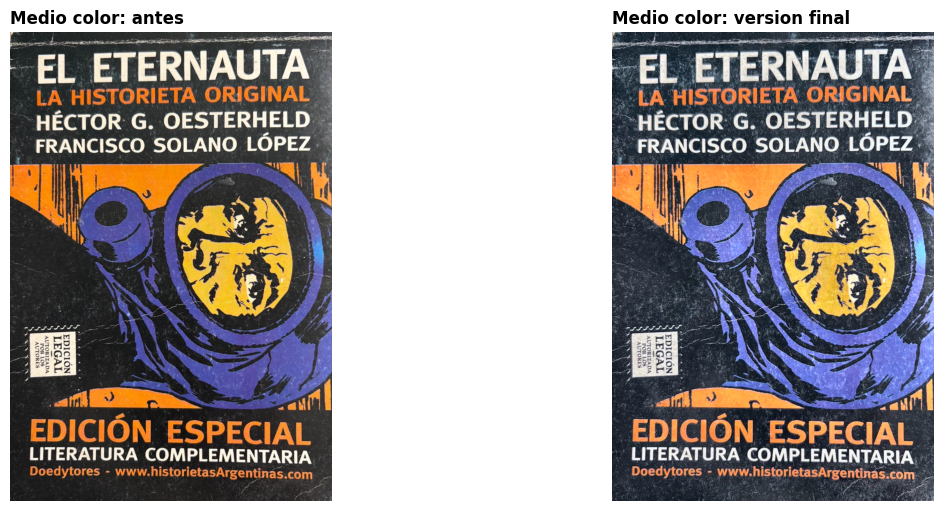

Salida guardada en: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\005 - TFI_1\salidas_tfi\medio_grafico_color_final.png


In [43]:
# Elegimos la estrategia 2 como versión final.
imagen_medio_color_final = imagen_medio_color_estrategia_2

justificacion_medio_color_final = (
    "Se elige la estrategia 2 (LAB + CLAHE) porque aborda el problema principal: "
    "la dominante cálida de la iluminación. HSV mejora la saturación global pero "
    "no corrige el sesgo de color, mientras que operar en LAB permite separar "
    "luminosidad y crominancia y actuar sobre cada uno con precisión. "
    "Límite del método: las rayaduras blancas sobre el fondo negro no se corrigen "
    "en ninguna de las dos estrategias, ya que requieren inpainting localizado "
    "y están fuera del alcance de una mejora global de color."
)
print(justificacion_medio_color_final)

if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")